In [1]:
import random
import sys
import os
import json
import torch
import torch.nn as nn
import numpy as np
import copy
from torch.utils.data import DataLoader
from omegaconf import OmegaConf

warnings = __import__('warnings')
warnings.filterwarnings('ignore')

# Настраиваем пути
sys.path.append(os.path.abspath('../../..'))

In [2]:
from DL.models.rotate_net import RotateNet
from DL.models.cascade_net import CascadeNet
from DL.trainers.model_trainer import ModelTrainer
from DL.losses.rotation_loss import angular_cosine_loss
from DL.data.rotated_combined_dataset import RotatedCombinedDataset
from DL.loggers.experiment_logger import ExperimentLogger
from DL.visualization.visualizer import ExperimentVisualizer

In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42) # Фиксируем сид

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [5]:
experiment_name = "cascade_rotatenet_comparison_8kb_vs_2kb"
logger = ExperimentLogger(experiment_name, base_dir=".")
visualizer = ExperimentVisualizer(logger)

In [6]:
# Создаем датасеты (по 1к примеров на класс для трейна, и по 500 для теста)
train_dataset = RotatedCombinedDataset(86000, seed=42, max_angle=150)
test_dataset = RotatedCombinedDataset(21500, seed=999, max_angle=150)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Датасеты готовы. Классов: {len(train_dataset.char_to_idx)}")

Датасеты готовы. Классов: 43


In [7]:
logger.log("=== ЭТАП 1: Предобучение RotateNet ===")
config_path_rot = '../../../DL/configs/rotatenet/rotatenet_spatial_32.json'
with open(config_path_rot, 'r') as f:
    config_rot = json.load(f)

rotatenet = RotateNet(config_rot).to(device)
opt_rot = torch.optim.Adam(rotatenet.parameters(), lr=1e-3)

epochs_rot = 20
for epoch in range(epochs_rot):
    rotatenet.train()
    running_loss = 0.0

    for batch in train_loader:
        images, _, targets = batch[0].to(device), batch[1].to(device), batch[2].to(device)

        opt_rot.zero_grad()
        pred_sin_cos, _ = rotatenet(images)
        loss = angular_cosine_loss(pred_sin_cos, targets, limit_deg=150.0)

        loss.backward()
        opt_rot.step()
        running_loss += loss.item() * images.size(0)

    avg_loss = running_loss / len(train_dataset)
    print(f"RotateNet | Эпоха {epoch+1}/{epochs_rot} | Angular Loss: {avg_loss:.4f}")

logger.log("RotateNet успешно обучен. Сохраняем состояние весов.")

# Фиксируем выученные веса RotateNet, чтобы использовать их для обеих моделей
pretrained_rotatenet_state = copy.deepcopy(rotatenet.state_dict())

RotateNet | Эпоха 1/20 | Angular Loss: 0.5681
RotateNet | Эпоха 2/20 | Angular Loss: 0.4385
RotateNet | Эпоха 3/20 | Angular Loss: 0.3875
RotateNet | Эпоха 4/20 | Angular Loss: 0.3509
RotateNet | Эпоха 5/20 | Angular Loss: 0.4469
RotateNet | Эпоха 6/20 | Angular Loss: 0.3690
RotateNet | Эпоха 7/20 | Angular Loss: 0.3206
RotateNet | Эпоха 8/20 | Angular Loss: 0.3848
RotateNet | Эпоха 9/20 | Angular Loss: 0.2977
RotateNet | Эпоха 10/20 | Angular Loss: 0.2703
RotateNet | Эпоха 11/20 | Angular Loss: 0.2647
RotateNet | Эпоха 12/20 | Angular Loss: 0.3655
RotateNet | Эпоха 13/20 | Angular Loss: 0.2452
RotateNet | Эпоха 14/20 | Angular Loss: 0.2328
RotateNet | Эпоха 15/20 | Angular Loss: 0.2260
RotateNet | Эпоха 16/20 | Angular Loss: 0.2199
RotateNet | Эпоха 17/20 | Angular Loss: 0.2214
RotateNet | Эпоха 18/20 | Angular Loss: 0.2344
RotateNet | Эпоха 19/20 | Angular Loss: 0.1979
RotateNet | Эпоха 20/20 | Angular Loss: 0.2225


In [8]:
def train_cascade_experiment(lenet_config_name: str, model_tag: str):
    logger.log(f"\n=== Запуск эксперимента: {model_tag} ===")

    # 1. Восстанавливаем RotateNet из сохраненных весов
    base_rotatenet = RotateNet(config_rot).to(device)
    base_rotatenet.load_state_dict(pretrained_rotatenet_state)

    # 2. Подготавливаем конфигурацию LeNet
    conf = OmegaConf.load(f'../../../DL/configs/lenet/{lenet_config_name}')
    conf.num_classes = len(train_dataset.char_to_idx)
    logger.save_config(OmegaConf.to_container(conf), filename=f"config_{model_tag}.json")

    # 3. Собираем каскад
    cascade_model = CascadeNet(OmegaConf.to_container(conf), base_rotatenet, use_polar=True, stn_iters=2).to(device)

    # Размораживаем RotateNet для End-to-End дообучения
    for param in cascade_model.rotatenet.parameters():
        param.requires_grad = True

    # 4. Настраиваем оптимизатор
    optimizer_cascade = torch.optim.Adam([
        {'params': cascade_model.classifier.parameters(), 'lr': 1e-3},
        {'params': cascade_model.rotatenet.parameters(), 'lr': 5e-5}
    ])

    trainer_cascade = ModelTrainer(
        model=cascade_model,
        optimizer=optimizer_cascade,
        criterion=nn.CrossEntropyLoss(),
        device=device,
        use_background_loss=True,
        bg_loss_alpha=10.0,
        bg_loss_n=2,
        logger=logger,
        visualizer=visualizer,
        model_name=model_tag
    )

    epochs_cascade = 30
    for epoch in range(1, epochs_cascade + 1):
        # Curriculum Learning
        if epoch <= 12:
            current_max_angle = 30 + ((epoch - 1) // 3) * 30
        else:
            current_max_angle = 150

        current_bg_alpha = 10.0 - (current_max_angle / 150.0) * 8.0

        train_dataset.max_angle = current_max_angle
        trainer_cascade.bg_loss_alpha = current_bg_alpha

        # Логируем прогресс в консоль
        print(f"[{model_tag}] Эпоха {epoch}/{epochs_cascade} | Угол: ±{current_max_angle}° | Alpha BG: {current_bg_alpha:.1f}")

        train_metrics = trainer_cascade.train_epoch(train_loader)
        val_metrics = trainer_cascade.evaluate(test_loader)

        # Логируем через визуализатор (он сам обновит график)
        trainer_cascade.history['train_loss'].append(train_metrics['loss'])
        trainer_cascade.history['train_acc'].append(train_metrics['acc'])
        trainer_cascade.history['train_bg_loss'].append(train_metrics['bg_loss'])
        trainer_cascade.history['val_loss'].append(val_metrics['loss'])
        trainer_cascade.history['val_acc'].append(val_metrics['acc'])

        if trainer_cascade.visualizer:
            trainer_cascade.visualizer.plot_live_losses(trainer_cascade.history, trainer_cascade.model_name, epoch, epochs_cascade)

    # Визуализация итогов
    print(f"\nСохранение метрик для {model_tag}...")
    return cascade_model

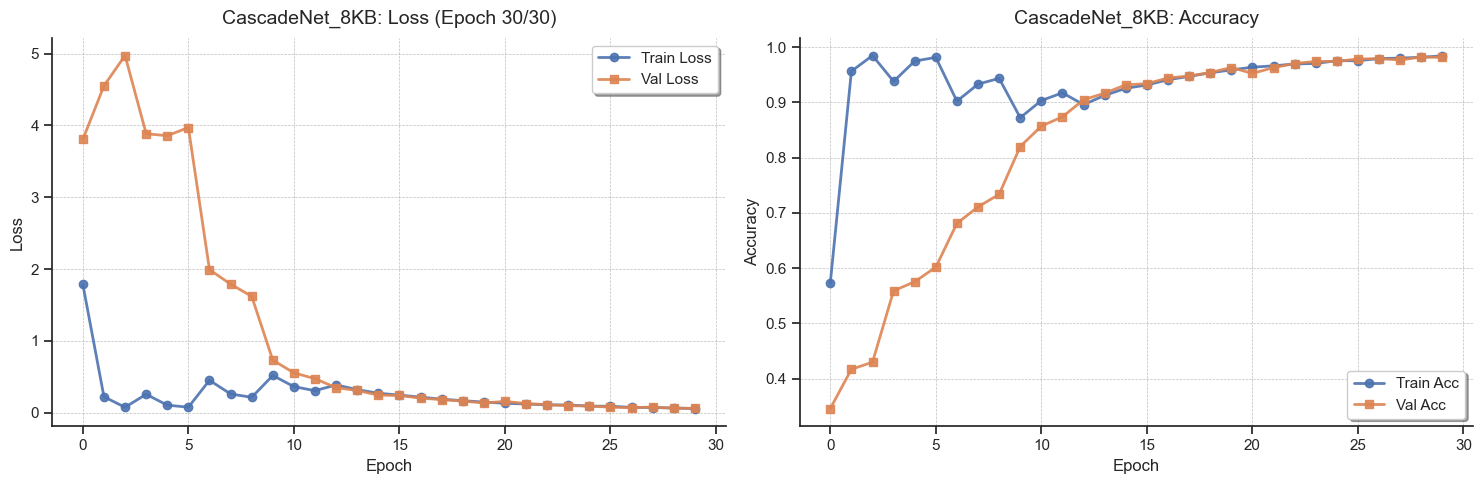


Сохранение метрик для CascadeNet_8KB...


In [9]:
cascade_8kb = train_cascade_experiment('lenet_8kb.json', model_tag="CascadeNet_8KB")

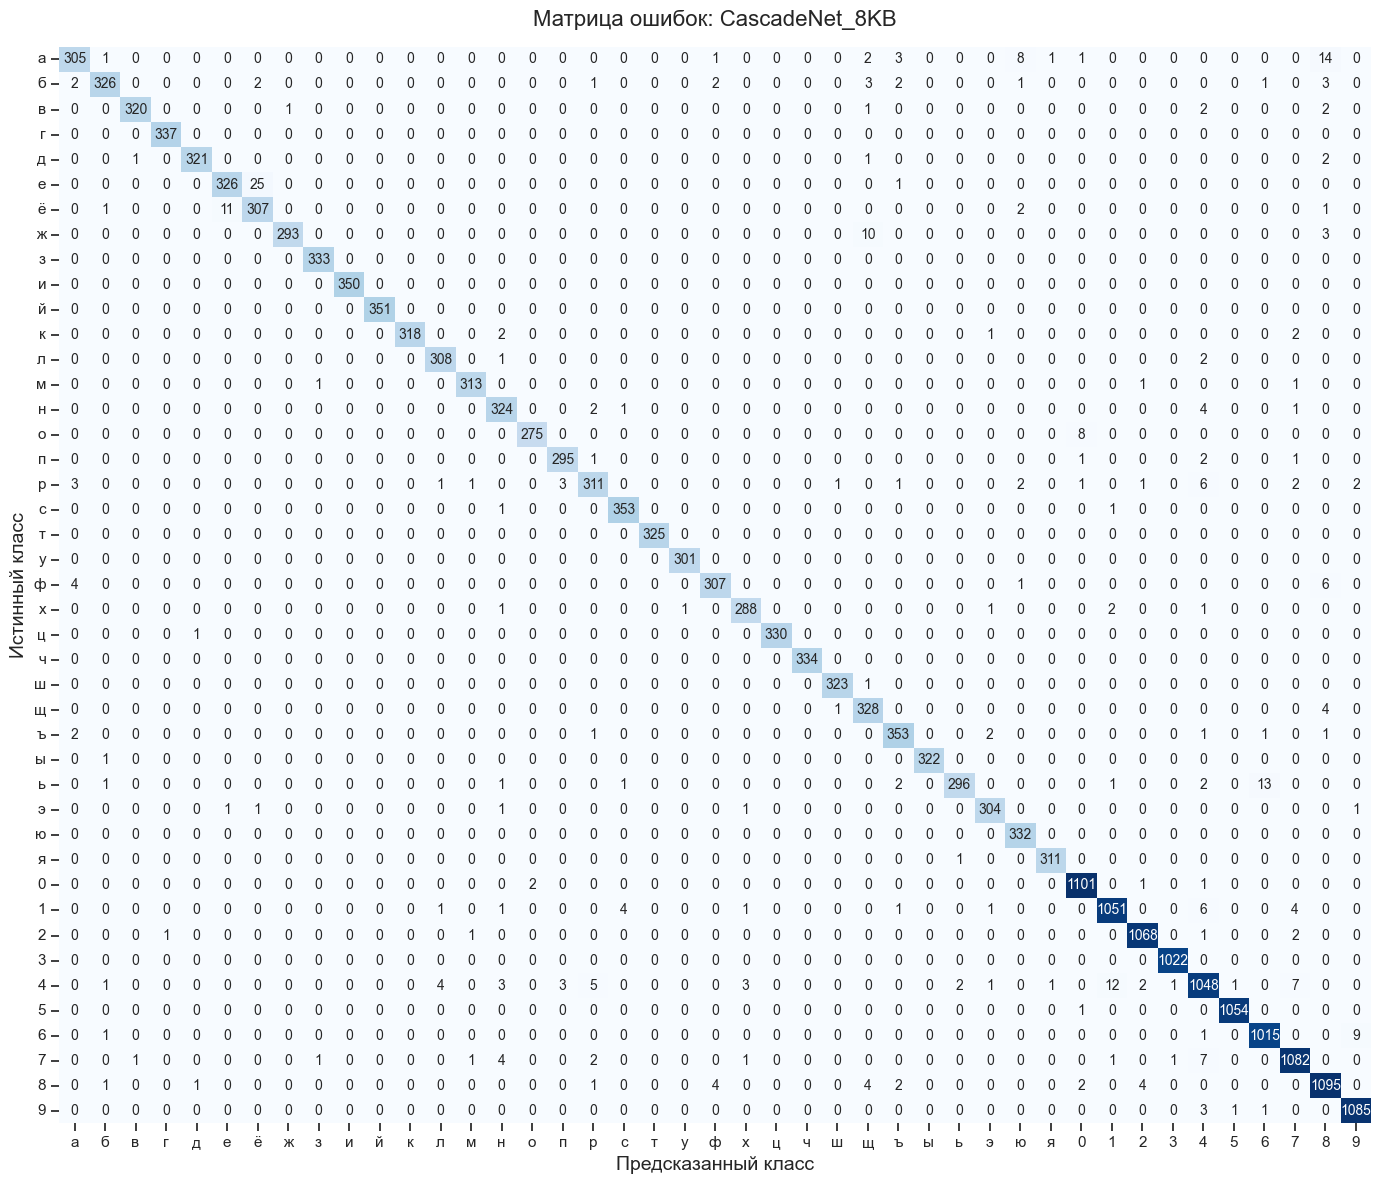

In [10]:
visualizer.plot_confusion_matrix(cascade_8kb, test_loader, test_dataset, device, model_name="CascadeNet_8KB")

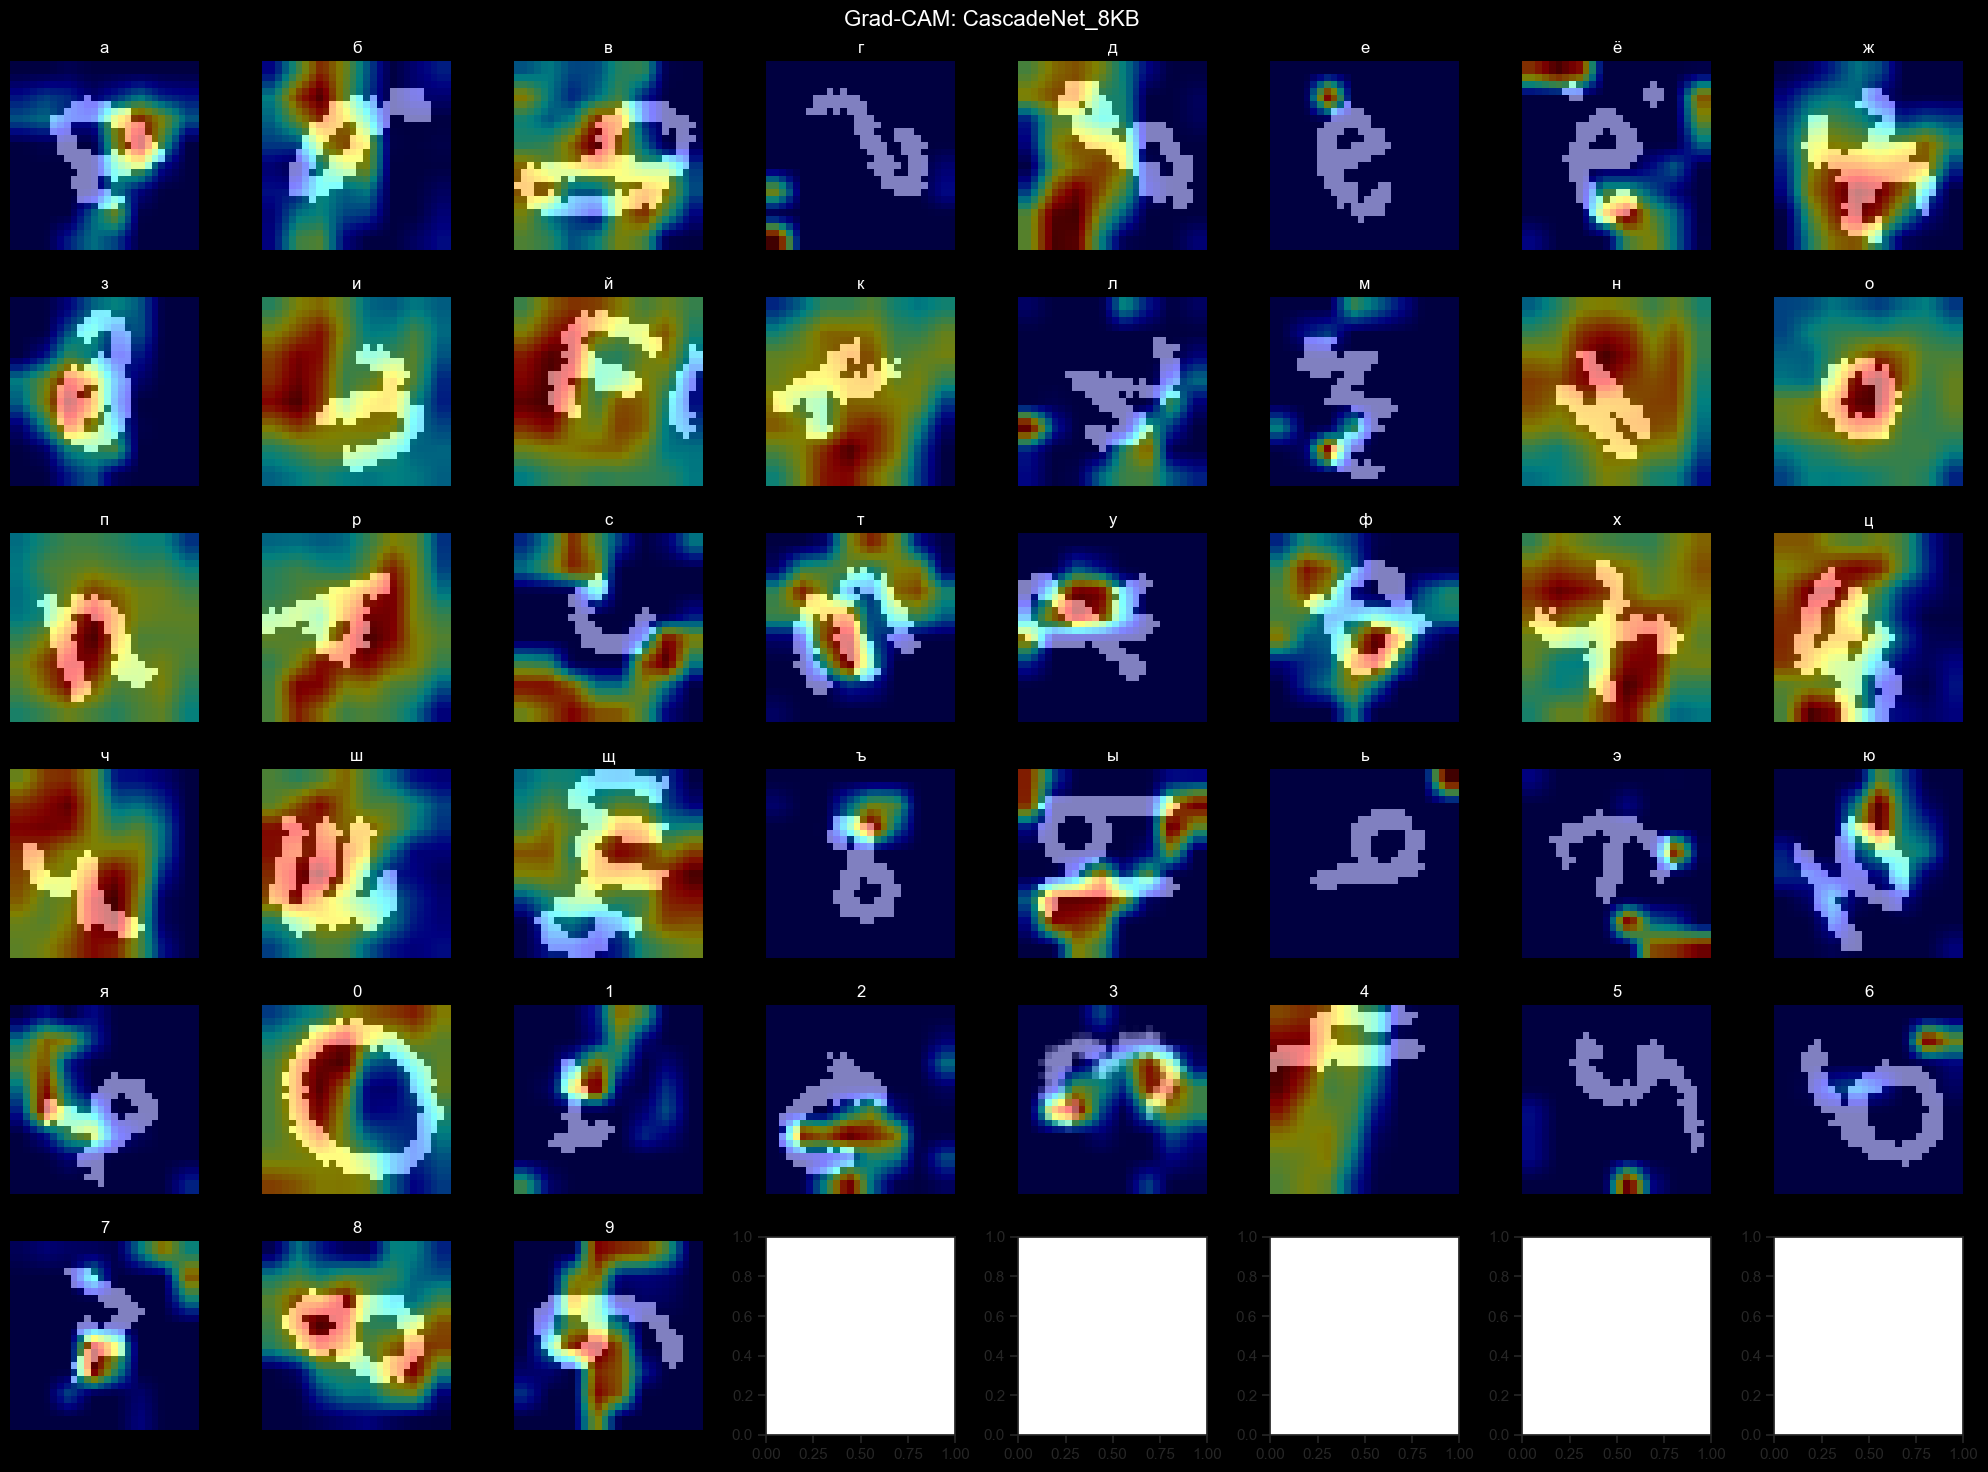

<Figure size 640x480 with 0 Axes>

In [11]:
visualizer.plot_gradcam(cascade_8kb, test_dataset, device, model_name="CascadeNet_8KB")

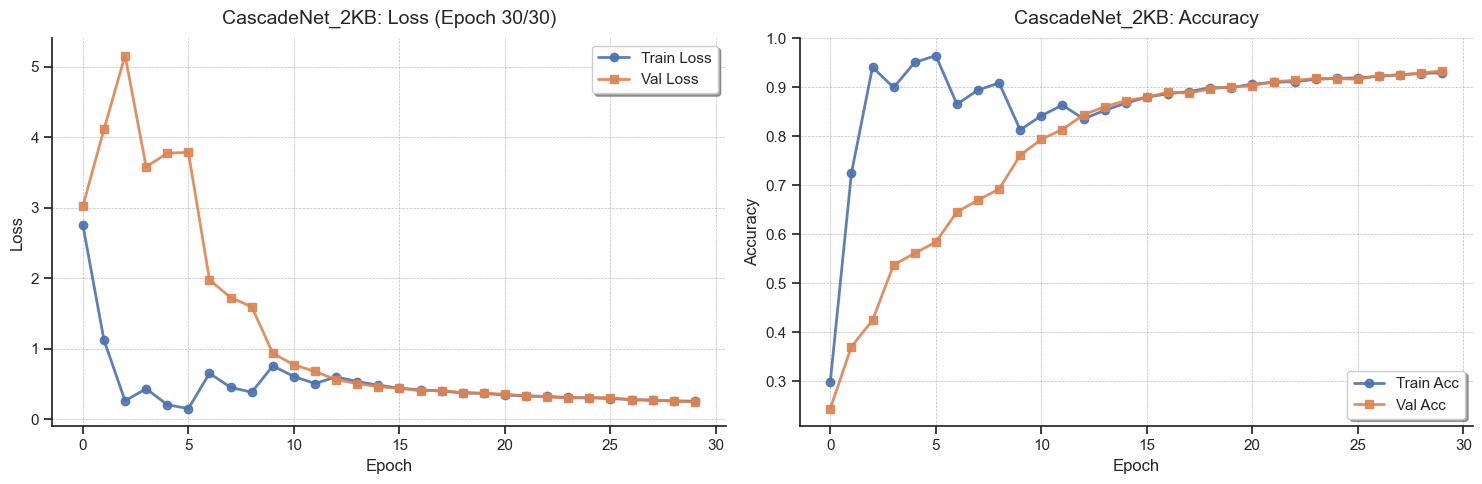


Сохранение метрик для CascadeNet_2KB...


In [12]:
cascade_2kb = train_cascade_experiment('lenet_2kb.json', model_tag="CascadeNet_2KB")

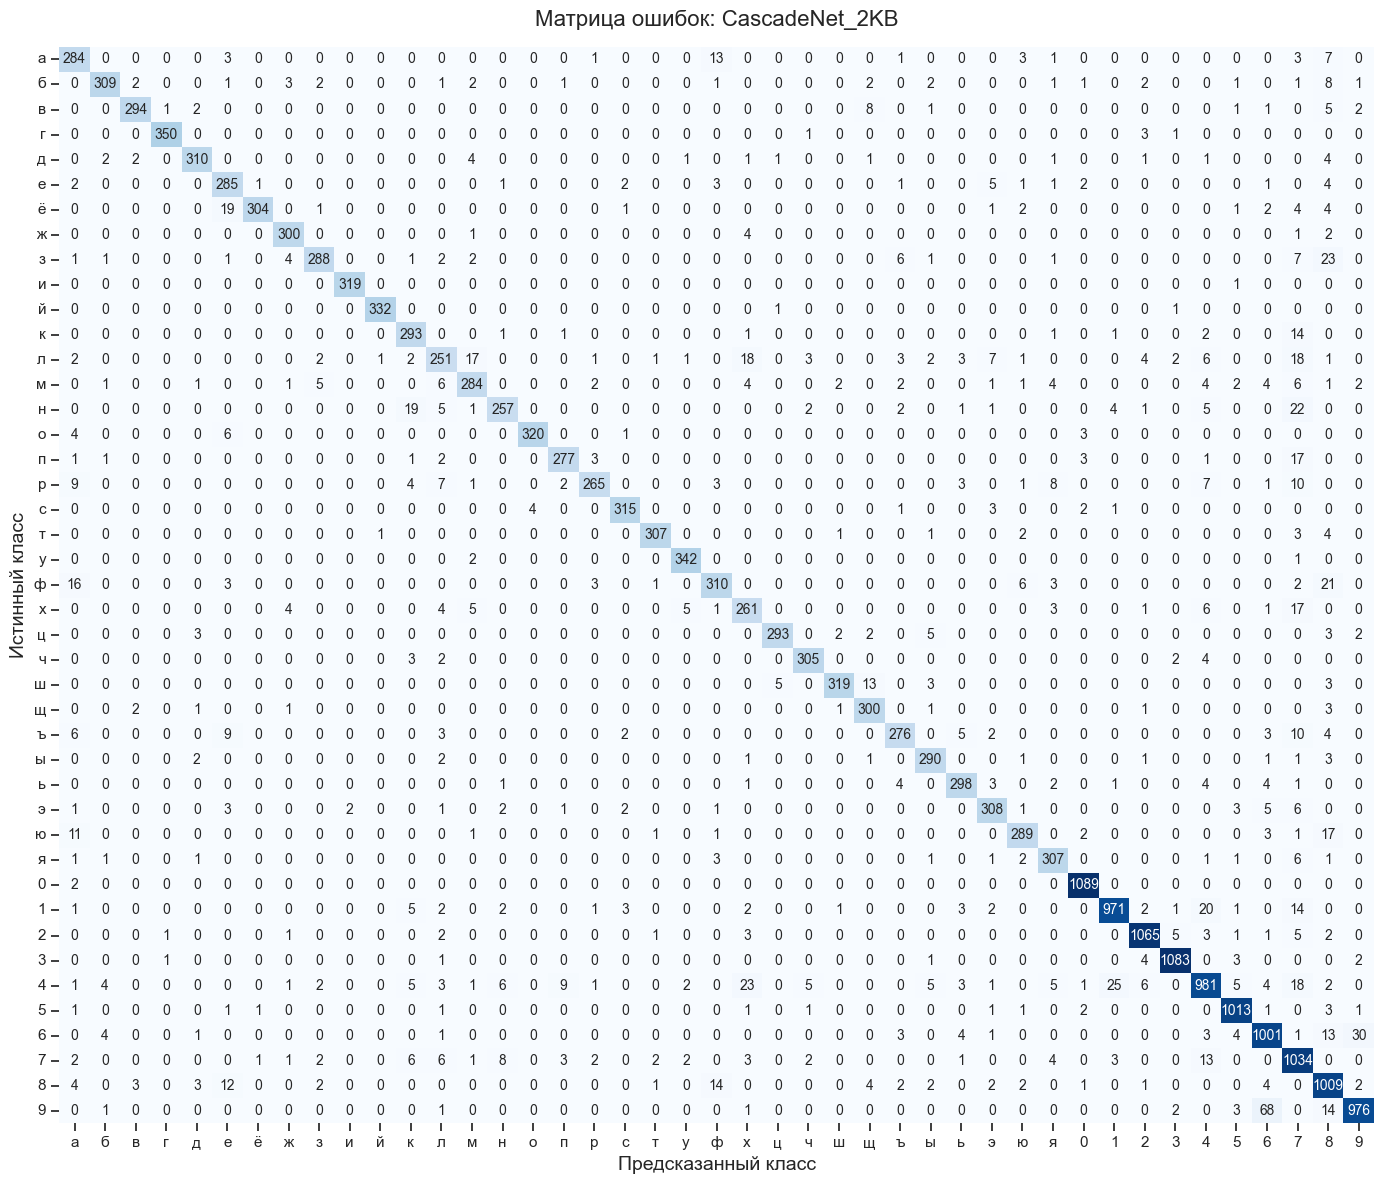

In [13]:
visualizer.plot_confusion_matrix(cascade_2kb, test_loader, test_dataset, device, model_name="CascadeNet_2KB")

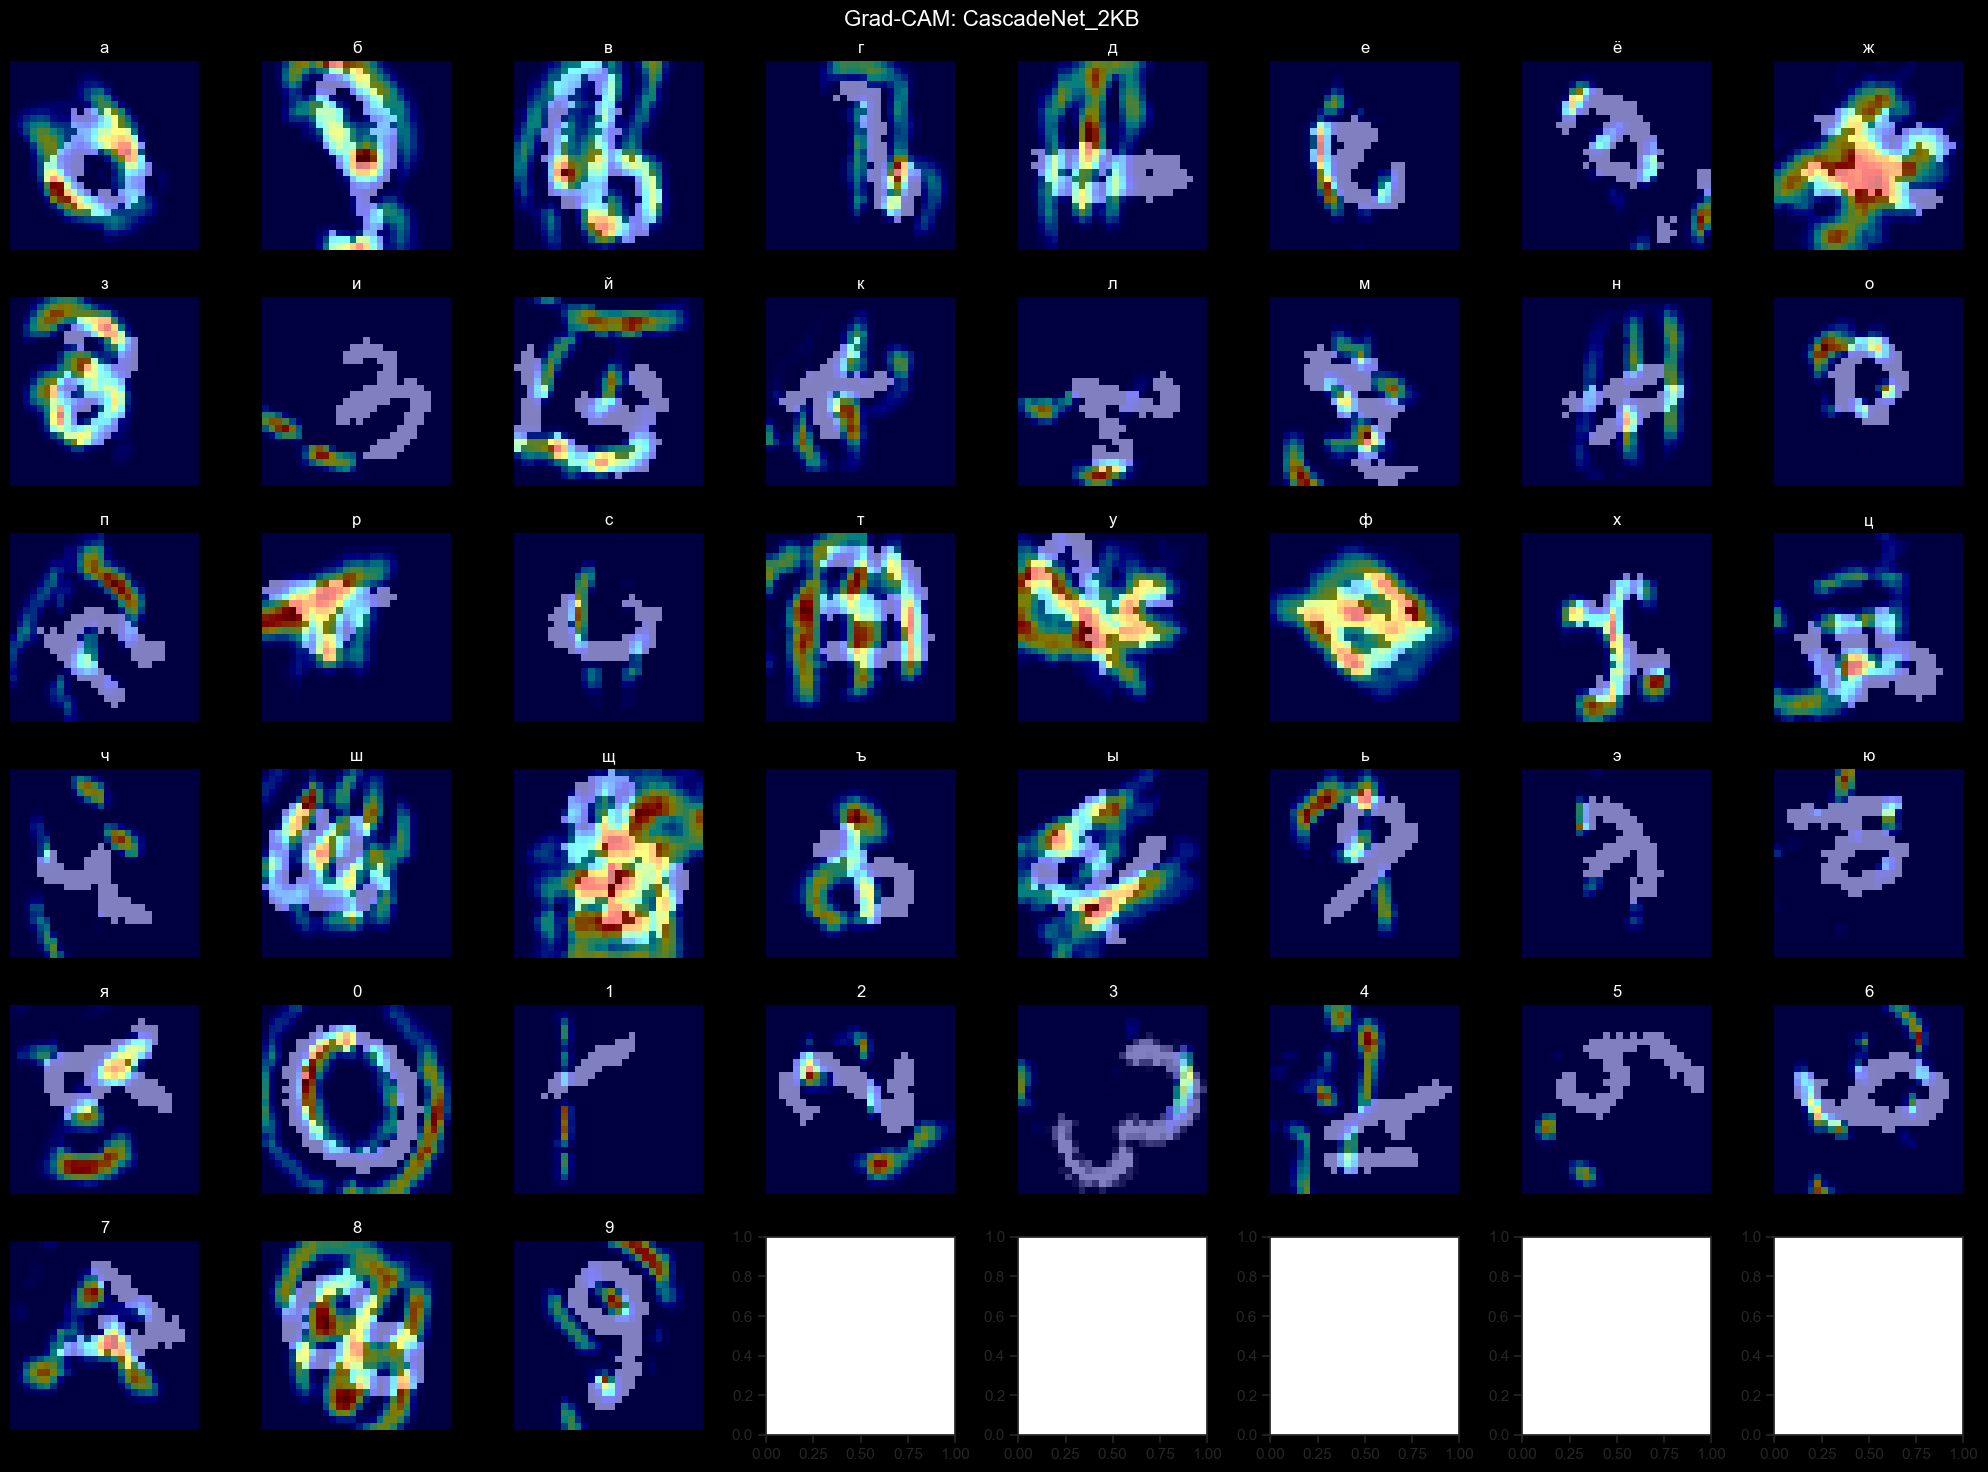

<Figure size 640x480 with 0 Axes>

In [14]:
visualizer.plot_gradcam(cascade_2kb, test_dataset, device, model_name="CascadeNet_2KB")